In [1]:
# step 1: import the required lib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# step 2
df = pd.read_csv("Hospital_Patient_Dataset.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,Diagnosis,Admission_Date,Discharge_Date,Doctor_Assigned,Bill_Amount,Insurance_Covered
0,PAT3000,17,Female,Diabetes,2023-06-11,2023-06-20,Dr. Rao,18709,No
1,PAT3001,50,Male,Heart Disease,2023-03-22,2023-03-31,Dr. Khan,45682,No
2,PAT3002,40,Female,Flu,2023-12-25,2023-12-29,Dr. Khan,9998,Yes
3,PAT3003,58,Male,Heart Disease,2023-06-24,2023-06-25,Dr. Patel,29906,No
4,PAT3004,75,Female,Flu,2023-02-05,2023-02-12,Dr. Sharma,36490,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         500 non-null    object
 1   Age                500 non-null    int64 
 2   Gender             500 non-null    object
 3   Diagnosis          500 non-null    object
 4   Admission_Date     500 non-null    object
 5   Discharge_Date     500 non-null    object
 6   Doctor_Assigned    500 non-null    object
 7   Bill_Amount        500 non-null    int64 
 8   Insurance_Covered  500 non-null    object
dtypes: int64(2), object(7)
memory usage: 35.3+ KB


In [5]:
df.isnull().sum()

Patient_ID           0
Age                  0
Gender               0
Diagnosis            0
Admission_Date       0
Discharge_Date       0
Doctor_Assigned      0
Bill_Amount          0
Insurance_Covered    0
dtype: int64

In [7]:
df.describe()

,Age,Bill_Amount
count,500.000000,500.000000
mean,44.394000,26230.642000
std,26.029172,14091.132927
min,1.000000,1021.000000
25%,21.000000,14331.000000
50%,44.000000,26600.500000
75%,68.000000,38283.500000
max,89.000000,49877.000000


<Axes: >

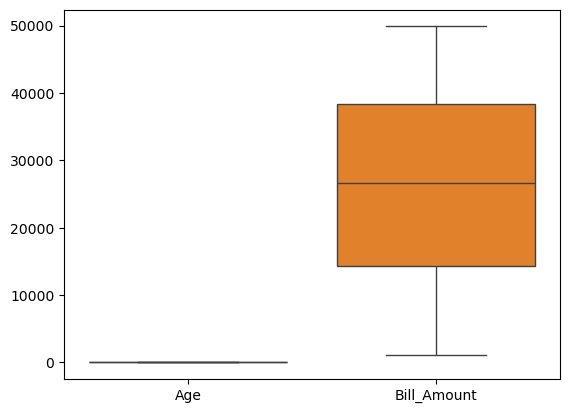

In [6]:
sns.boxplot(df)

<Axes: ylabel='Patient_ID'>

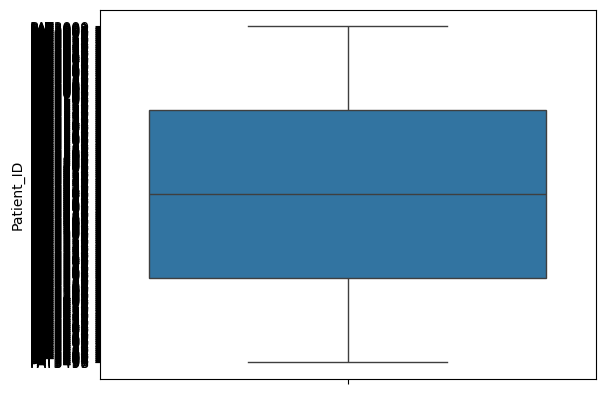

In [11]:
sns.boxplot(df['Patient_ID'])

In [8]:
# handled the outlier
outlier_column = ["Age","Bill_Amount"]
for col in outlier_column:
    # find the Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # find the IQR
    IQR = Q3 - Q1

    # find the upper bound and lower  bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # find the outlier
    outlier = ((df[col] < lower_bound )| (df[col] > upper_bound))
    outlier.shape[0]

    # handle the outlier 
    df[col] =df[col].clip(lower = lower_bound, upper = upper_bound)

In [10]:
# handle cat columns
df['Gender'].replace({'Male':1,'Female':0},inplace = True)

C:\Users\Soham\AppData\Local\Temp\ipykernel_12624\3617571964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'Male':1,'Female':0},inplace = True)
C:\Users\Soham\AppData\Local\Temp\ipykernel_12624\3617571964.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].re